# Seasonal Agriculture Performance Analysis

### Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

### Project Goal

Investigating how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.


# 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.


# 2. Project Objectives

* Exploring and understanding the dataset.
* Clean and prepare the data for analysis.
* Examining agricultural performance varies across seasons.
* Identifying important seasonal patterns and trends.
* Investigating relationships between seasonal conditions and agricultural outcomes.
* Comparing relevant groups within different seasons.
* Identifying significant differences or unusual patterns.
* Applying appropriate statistical and visualization techniques.
* Interpret findings based on evidence from the dataset.
* Develop meaningful conclusions and data-driven recommendations.

# 3. Dataset

### The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load the dataset

file_path = "/content/sample_data/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# 4. Initial Data Understanding
### Provides a basic understanding of the dataset before performing analysis. Checks the dataset structure, number of rows/columns, column names and basic information.

In [3]:
# Number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 4000
Number of columns: 28


In [4]:
# Top 5 rows

df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
# Bottom 5 rows

df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [6]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [7]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [8]:
# Data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [10]:
# Categorical summary

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


# 5. Data Quality Analysis

### Checking and preparing the data before analysis. Checks missing values, duplicates and data types and prepares the dataset for analysis.


In [11]:
# Check duplicate records

print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


In [12]:
# Remove duplicate records

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [13]:
# Check data types

df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [14]:
# Check missing values

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [15]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])



Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [16]:
# Handle Missing Values: Fill missing environmental values with median

df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

# For Yield, we will remove records where yield is missing
# because Yield is an important performance measure.

df = df.dropna(subset=["Yield_Tonnes_Ha"]).reset_index(drop=True)

print("Missing values handled.")

Missing values handled.


In [17]:
# Check remaining missing values

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


# 6. Feature or Variable Review

### Reviewing the available variables and classifying them conceptually as; Identifier variables, Categorical variables, Numerical variables, Environmental variables, Operational variables, Production/performance variables, Economic variables

In [18]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


# 7. Statistical Analysis
### Calculating descriptive statistics such as mean, median, standard deviation, minimum, maximum, range and IQR.

In [19]:
# Descriptive statistics

stats = df[numeric_columns].describe().T

stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"3,968.00",7.89,4.22,0.50,4.26,7.91,11.65,15.00,14.50,7.39
Rainfall_mm,"3,968.00",601.52,287.09,80.00,372.08,582.00,832.38,"1,395.20","1,315.20",460.30
Avg_Temperature_C,"3,968.00",26.83,3.81,16.20,24.00,27.00,29.60,39.70,23.50,5.60
Humidity_pct,"3,968.00",63.26,11.97,25.00,54.90,63.10,72.00,95.00,70.00,17.10
Sunlight_Hours_Day,"3,968.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"3,968.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"3,968.00",26.53,6.67,8.00,21.80,26.40,31.30,47.00,39.00,9.50
Nitrogen_kg_ha,"3,968.00",120.20,31.17,40.00,98.50,120.05,141.20,220.00,180.00,42.70
Phosphorus_kg_ha,"3,968.00",57.80,17.01,15.00,46.30,57.50,69.40,120.00,105.00,23.10
Potassium_kg_ha,"3,968.00",104.71,27.73,30.00,86.17,105.10,123.50,200.00,170.00,37.33


In [20]:
# Mean, Median and Standard Deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.91,4.22,0.50,15.00
Rainfall_mm,601.52,582.00,287.09,80.00,"1,395.20"
Avg_Temperature_C,26.83,27.00,3.81,16.20,39.70
Humidity_pct,63.26,63.10,11.97,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.53,26.40,6.67,8.00,47.00
Nitrogen_kg_ha,120.20,120.05,31.17,40.00,220.00
Phosphorus_kg_ha,57.80,57.50,17.01,15.00,120.00
Potassium_kg_ha,104.71,105.10,27.73,30.00,200.00


In [21]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(
    ["mean", "median", "std"]
)

season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.95   8.18 4.28      848.69 852.50 183.49   
Rabi                 7.75   7.68 4.18      437.93 432.70 175.51   
Zaid                 8.09   7.99 4.17      304.25 288.00 157.26   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.84  71.90 8.83   
Rabi               23.50  23.50 2.46        57.92  58.10 9.01   
Zaid               31.05  31.00 2.56        51.99  52.30 9.08   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.09   
Zaid                 8.18   8.20 1.05    6.69   6.65 0.64             19.27   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         119.96 119.65 31.16            58.09  57.40 17.14   
Rabi    24.00 4.93         120.31 120.20 31.02            57.32  57.70 17.15   
Zaid    19.10 4.95         120.65 120.20 31.64            58.28  57.50 16.21   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.32 104.80 27.02           187.04 188.15 60.92   
Rabi            103.81 104.80 28.85           185.28 184.80 59.93   
Zaid            105.36 106.30 26.70           184.23 183.50 59.37   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.17 1.96               0.82   0.82 0.10   
Rabi                 5.03   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.16   5.18 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.64   1.95 14.42             46.44  13.27 135.95   
Rabi              5.08   1.66 12.83             41.34  11.14 121.88   
Zaid              4.67   1.45 11.32             39.15   9.98 112.44   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,846.63 25,805.50 30,297.50     532,074.15 524,937.00   
Rabi                44,770.59 26,085.00 30,311.41     513,628.29 506,997.00   
Zaid                43,957.76 25,668.00 29,918.89     543,254.52 534,995.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,396.53  711,441.28 521,441.50 709,479.86 179,367.12  39,074.50   
Rabi   287,909.86  601,825.55 438,156.00 585,551.28  88,197.25  -3,978.00   
Zaid   297,512.46  516,662.12 375,119.00 503,360.25 -26,592.40 -61,563.00   

                  Water_Used_m3             

# 8. Univariate Analysis
### Studying one variable at a time using graphs such as countplots and histograms.

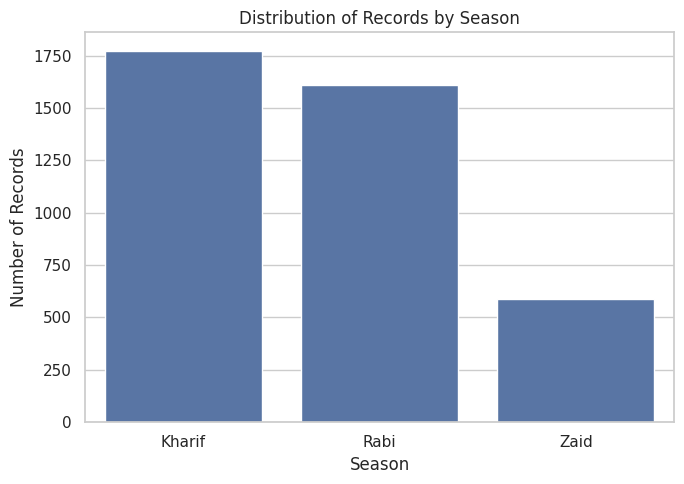

In [22]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Season")

plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

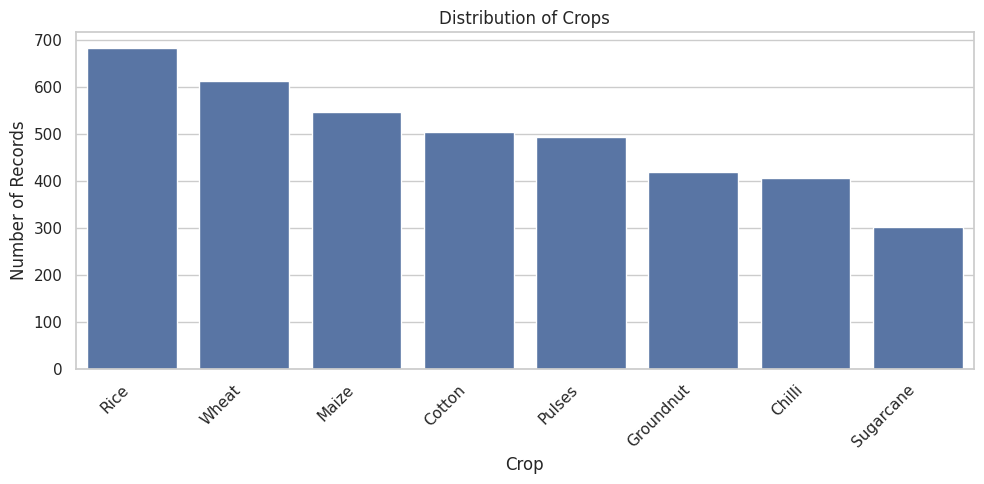

In [23]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

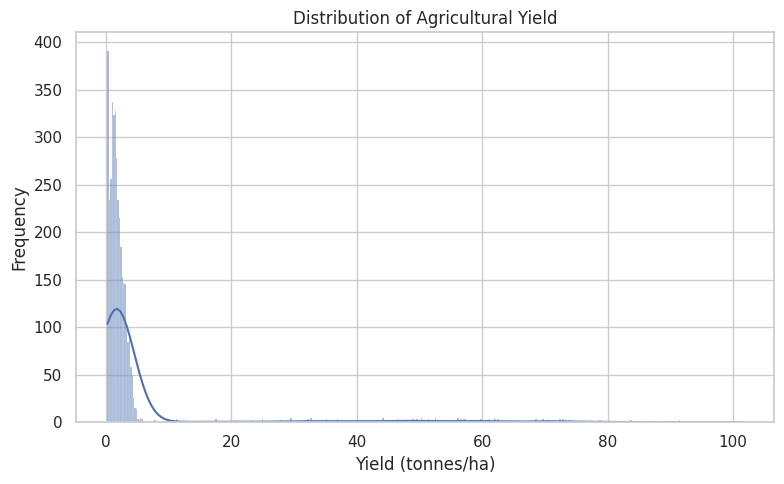

In [24]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

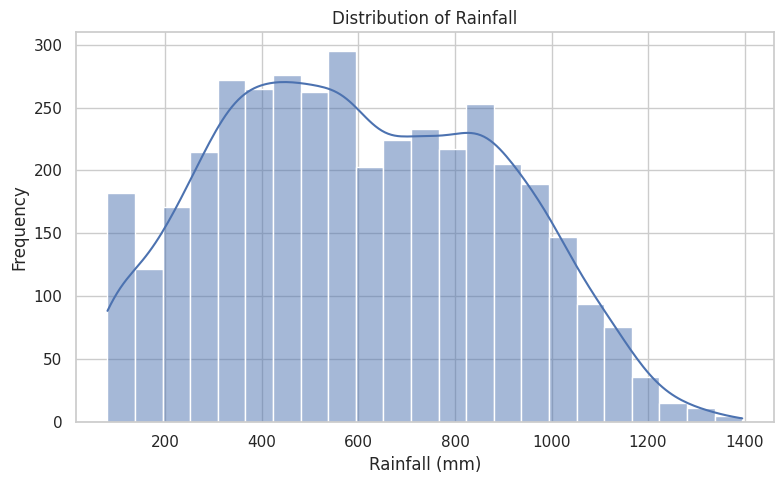

In [25]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Rainfall_mm", kde=True)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

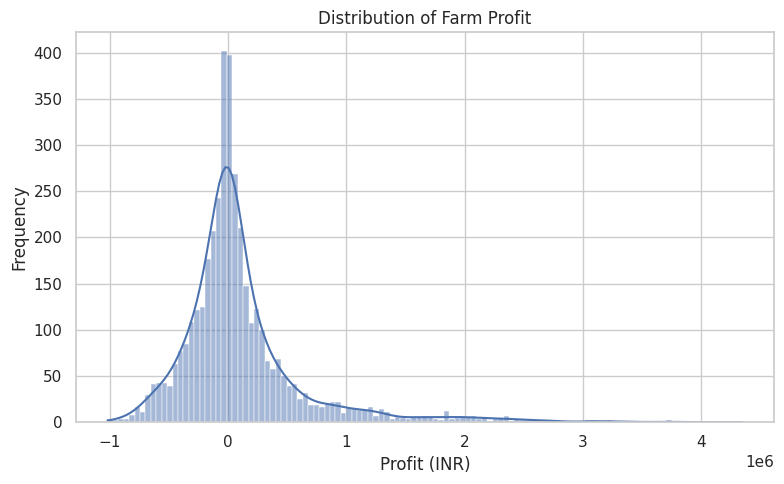

In [26]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Profit_INR", kde=True)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 9. Outlier Analysis
### Identifying unusual/extreme values using boxplots and the IQR method without automatically deleting them.

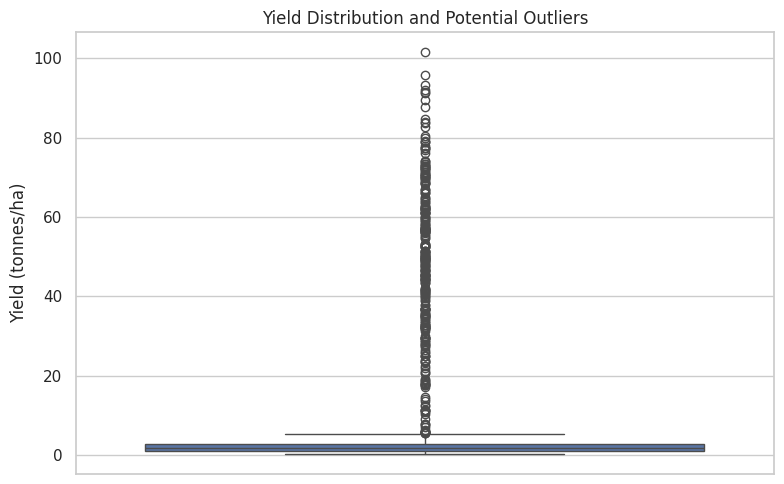

In [27]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, y="Yield_Tonnes_Ha")

plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

In [28]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count",
    ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-697,449.75","764,370.25",398,10.03
14,Production_Tonnes,-23.97,53.39,329,8.29
20,Water_Efficiency_t_per_1000m3,-3.57,10.39,319,8.04
13,Yield_Tonnes_Ha,-1.63,5.52,302,7.61
19,Water_Used_m3,"-6,084.88","16,176.12",273,6.88
17,Revenue_INR,"-729,514.00","1,773,516.00",240,6.05
9,Potassium_kg_ha,30.19,179.49,33,0.83
4,Sunlight_Hours_Day,4.35,10.35,26,0.66
8,Phosphorus_kg_ha,11.65,104.05,17,0.43
10,Fertilizer_kg_ha,18.96,351.86,15,0.38


# 10. Bivariate Analysis
### Examining relationships between two variables, such as Season vs Yield and Rainfall vs Yield.

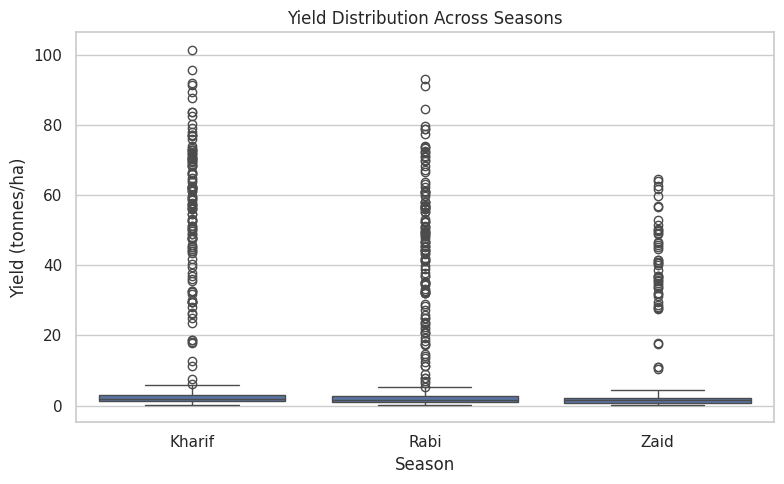

In [29]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

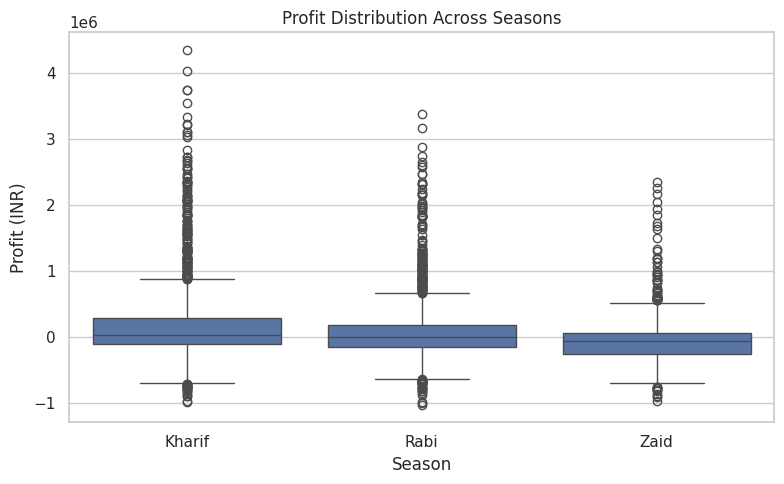

In [30]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

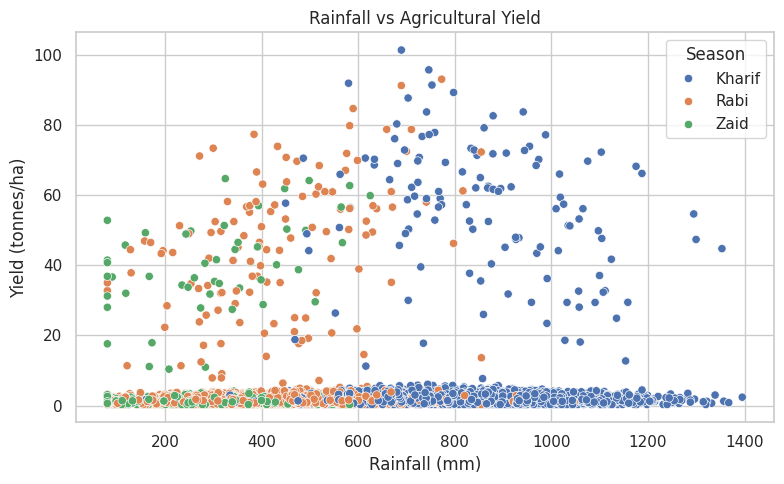

In [31]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

# 11. Farm Area and Production Analysis
### Examining how farm area relates to agricultural production.

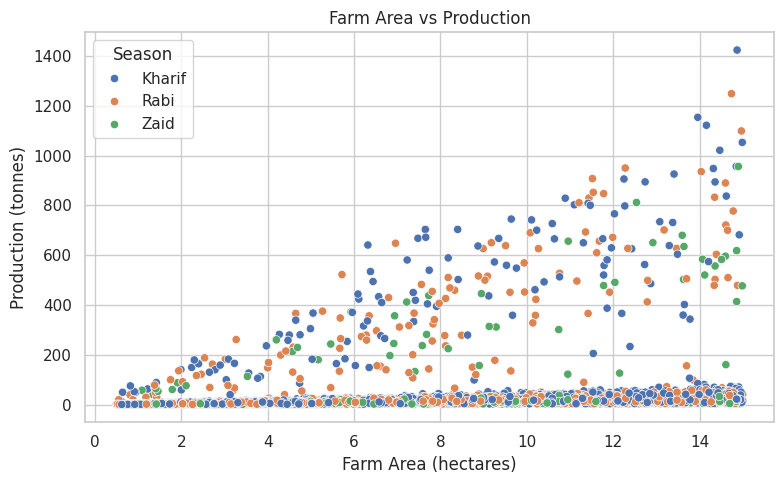

In [32]:
# Farm Area vs Production

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Season"
)

plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")

plt.tight_layout()
plt.show()

# 12. Yield and Profit Analysis
### Studying the relationship between agricultural yield and farm profit.

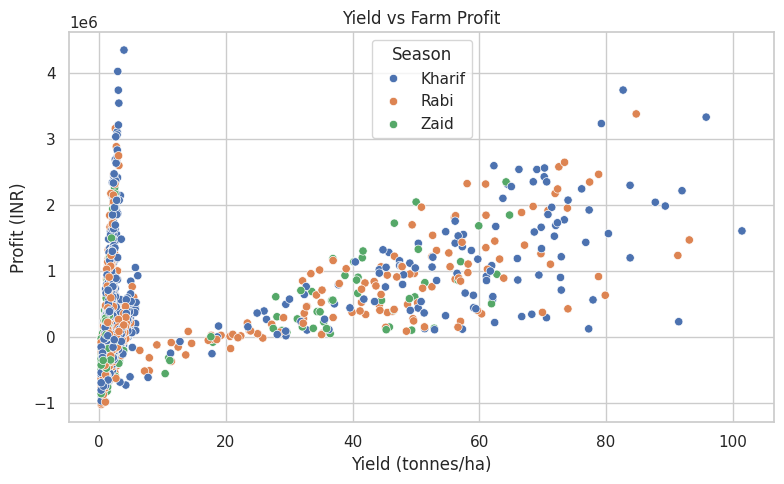

In [33]:
# Yield vs Profit

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season"
)

plt.title("Yield vs Farm Profit")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

# 13. Seasonal Performance Analysis
### Comparing yield, production and profit across Kharif, Rabi and Zaid seasons.

In [34]:
# Average performance by season

season_performance = df.groupby("Season")[
    ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR"]
].mean()

season_performance

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Season,,,
Kharif,5.64,46.44,"179,367.12"
Rabi,5.08,41.34,"88,197.25"
Zaid,4.67,39.15,"-26,592.40"


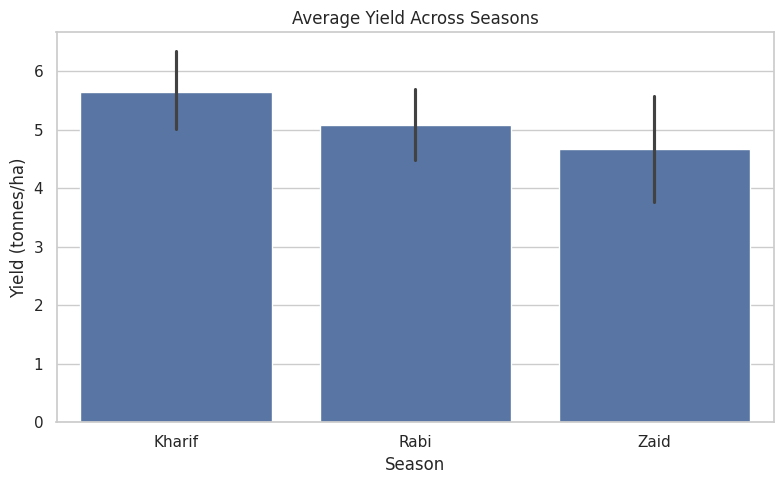

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

# 14. Environmental Analysis
### Examining environmental factors such as rainfall across different seasons.

In [36]:
# Average rainfall by season

rainfall_season = df.groupby("Season")["Rainfall_mm"].mean()

rainfall_season

,Rainfall_mm
Season,
Kharif,848.69
Rabi,437.93
Zaid,304.25


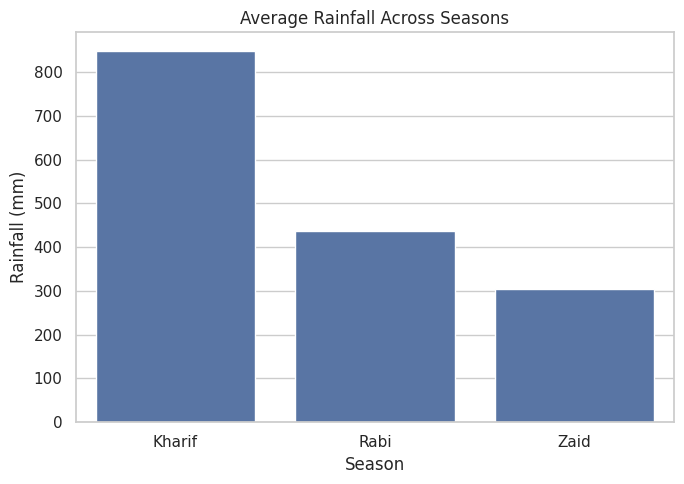

In [37]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=rainfall_season.index,
    y=rainfall_season.values
)

plt.title("Average Rainfall Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.show()

# 15. Temperature and Humidity Analysis
### Comparing temperature and humidity conditions between seasons

In [38]:
# Temperature and humidity by season

environment_summary = df.groupby("Season")[
    ["Avg_Temperature_C", "Humidity_pct"]
].mean()

environment_summary

,Avg_Temperature_C,Humidity_pct
Season,,
Kharif,28.45,71.84
Rabi,23.50,57.92
Zaid,31.05,51.99


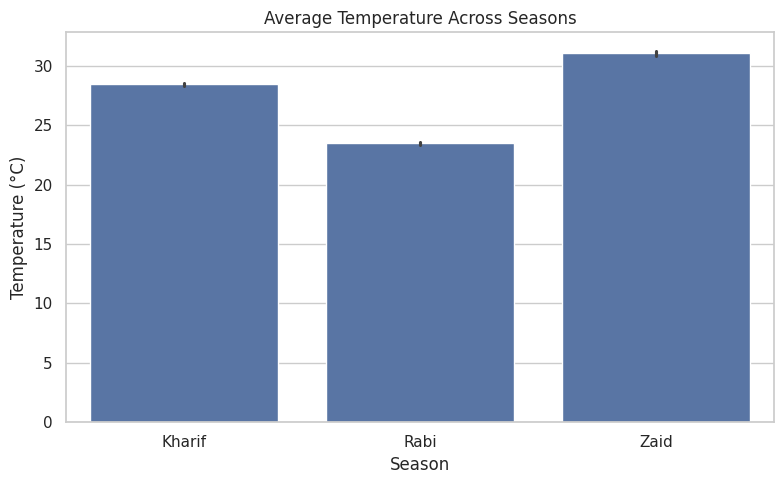

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Average Temperature Across Seasons")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

# 16. Soil Analysis
### Examining soil characteristics such as soil pH and soil moisture across seasons.

In [40]:
# Soil conditions by season

soil_summary = df.groupby("Season")[
    ["Soil_pH", "Soil_Moisture_pct"]
].mean()

soil_summary

,Soil_pH,Soil_Moisture_pct
Season,,
Kharif,6.73,31.15
Rabi,6.67,24.09
Zaid,6.69,19.27


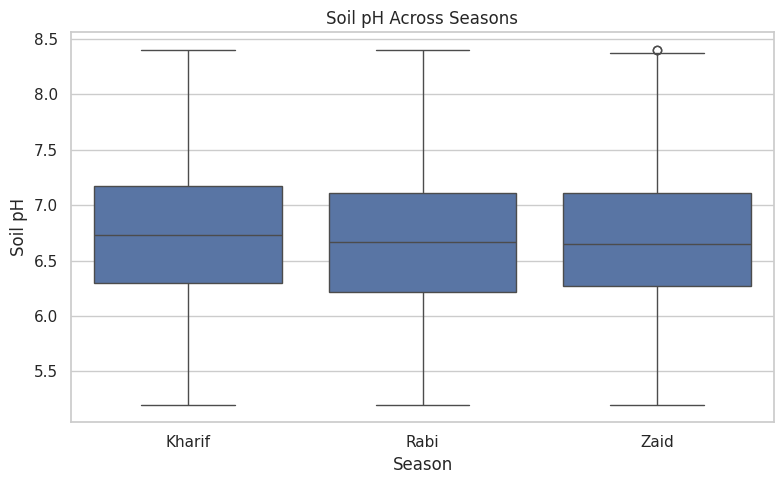

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Soil_pH"
)

plt.title("Soil pH Across Seasons")
plt.xlabel("Season")
plt.ylabel("Soil pH")

plt.tight_layout()
plt.show()

# 17. Water Usage Analysis
### Studying the amount of water used for agriculture across different seasons.

In [42]:
# Average water usage by season

water_summary = df.groupby("Season")[
    ["Water_Used_m3", "Water_Efficiency_t_per_1000m3"]
].mean()

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,"6,094.05",5.91
Rabi,"5,837.24",5.18
Zaid,"6,423.08",4.44


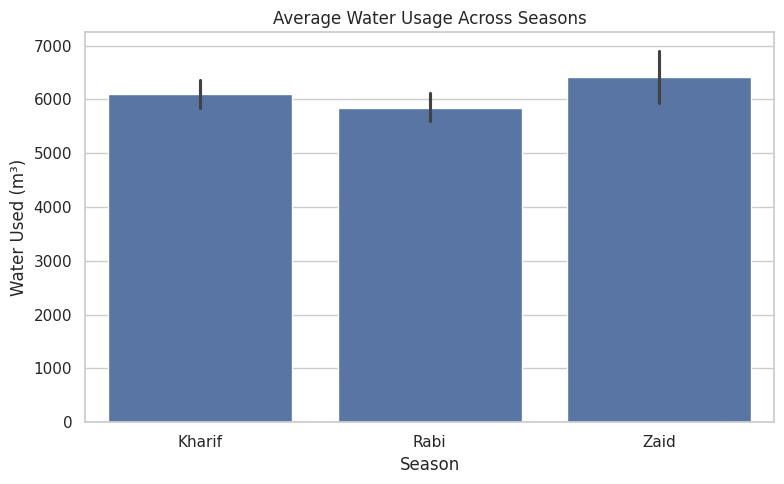

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3"
)

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.show()

# 18. Water Efficiency Analysis
### Examining how efficiently water is being used to produce agricultural output.

In [44]:
# Water efficiency by season

water_efficiency = df.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean()

water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.91
Rabi,5.18
Zaid,4.44


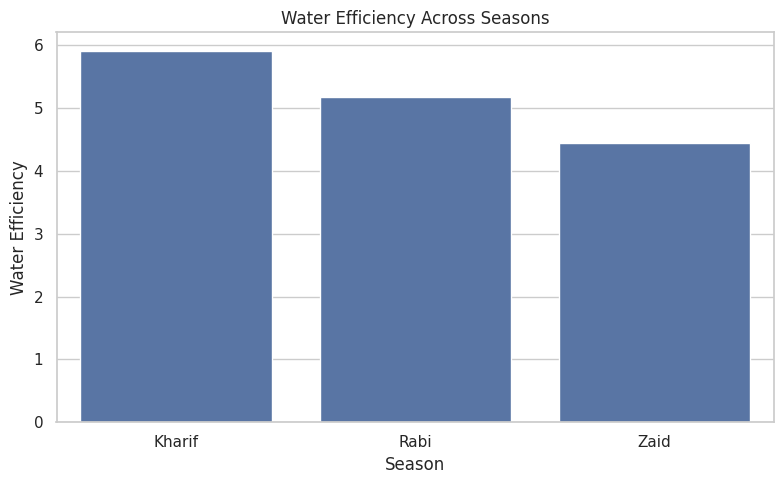

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title("Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")

plt.tight_layout()
plt.show()

# 19. Economic Analysis
### Comparing total cost, market price and profit across seasons.

In [46]:
# Economic summary

economic_summary = df.groupby("Season")[
    ["Total_Cost_INR", "Market_Price_INR_Tonne", "Profit_INR"]
].mean()

economic_summary

,Total_Cost_INR,Market_Price_INR_Tonne,Profit_INR
Season,,,
Kharif,"532,074.15","44,846.63","179,367.12"
Rabi,"513,628.29","44,770.59","88,197.25"
Zaid,"543,254.52","43,957.76","-26,592.40"


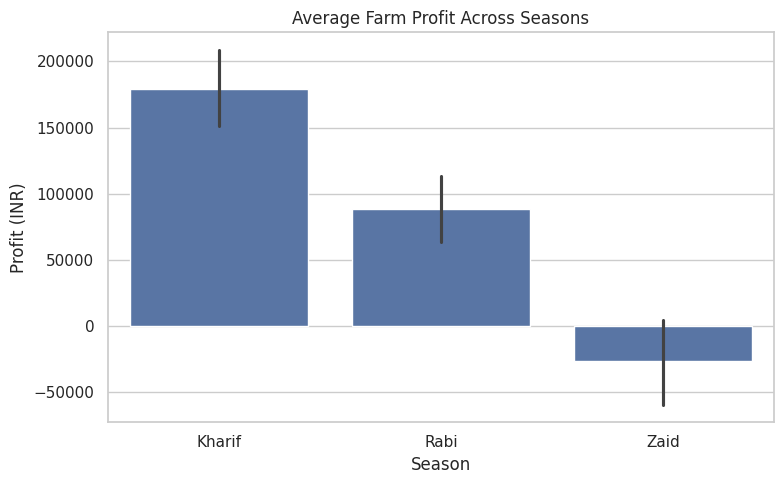

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Average Farm Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

# 20. Crop Performance Analysis
### Comparing the average yield of different crops.

In [48]:
# Average yield by crop

crop_yield = df.groupby("Crop")[
    "Yield_Tonnes_Ha"
].mean().sort_values(ascending=False)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.94
Maize,2.72
Rice,2.44
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


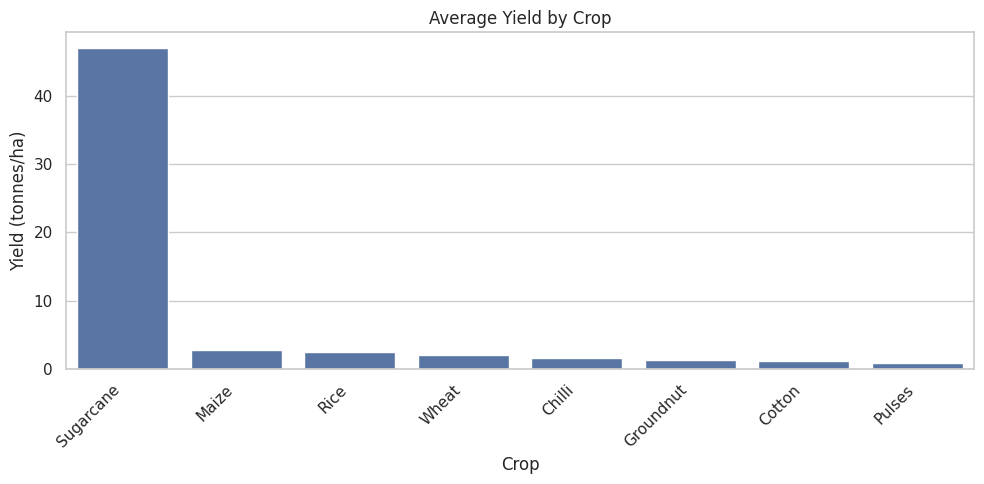

In [49]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=crop_yield.index,
    y=crop_yield.values
)

plt.xticks(rotation=45, ha="right")
plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")

plt.tight_layout()
plt.show()

# 21. Crop Performance Across Seasons
### Examining how different crops perform in different seasons.

In [50]:
# Average crop yield across seasons

crop_season_yield = df.groupby(
    ["Crop", "Season"]
)["Yield_Tonnes_Ha"].mean().reset_index()

crop_season_yield

,Crop,Season,Yield_Tonnes_Ha
0,Chilli,Kharif,1.73
1,Chilli,Rabi,1.46
2,Chilli,Zaid,1.18
3,Cotton,Kharif,1.37
4,Cotton,Rabi,1.19
5,Cotton,Zaid,0.95
6,Groundnut,Kharif,1.48
7,Groundnut,Rabi,1.22
8,Groundnut,Zaid,1.04
9,Maize,Kharif,2.97


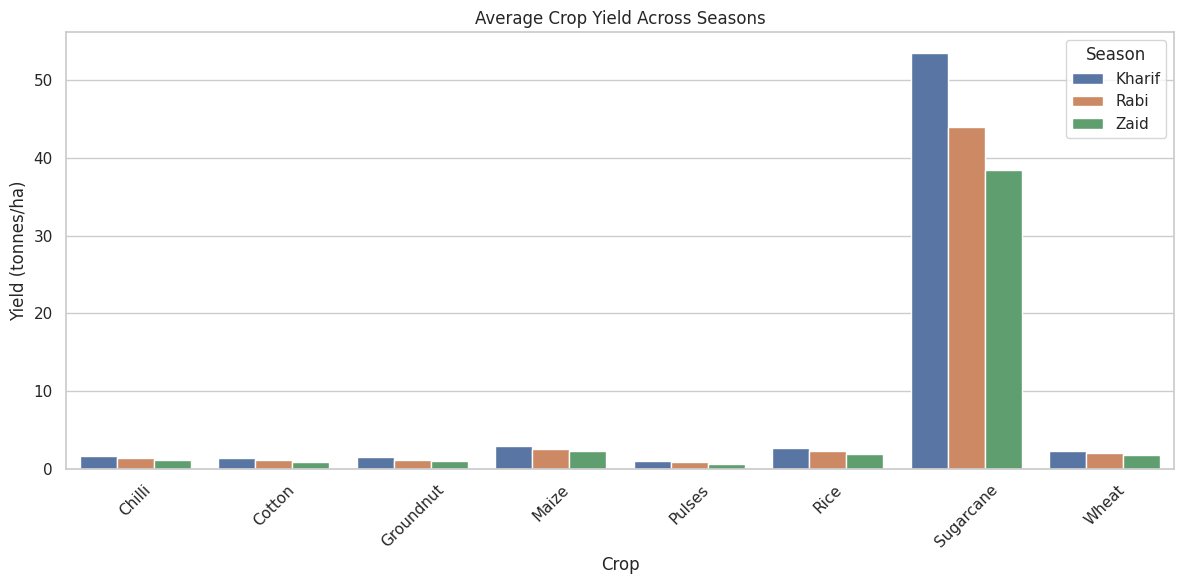

In [51]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=crop_season_yield,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 22. Irrigation Method Analysis
### Examines the distribution of irrigation methods and their relationship with yield.

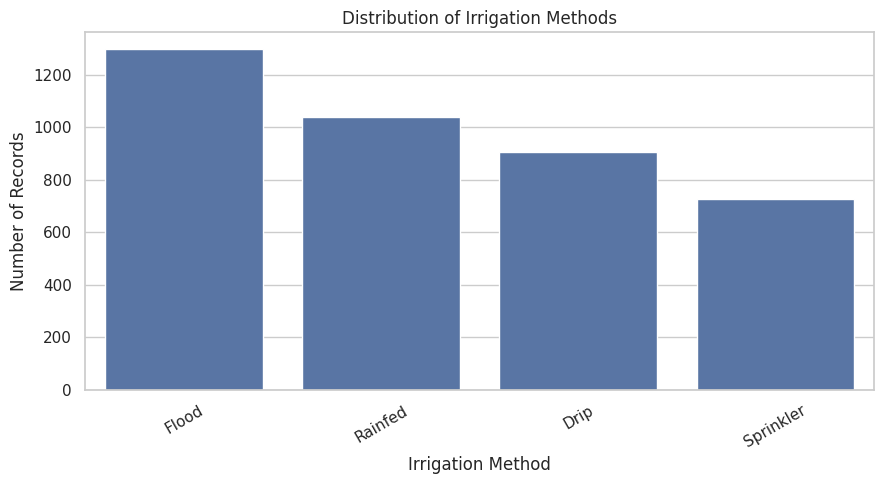

In [52]:
# Irrigation method distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Irrigation_Method",
    order=df["Irrigation_Method"].value_counts().index
)

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [53]:
# Average yield by irrigation method

irrigation_yield = df.groupby(
    "Irrigation_Method"
)["Yield_Tonnes_Ha"].mean()

irrigation_yield

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.62
Flood,4.90
Rainfed,4.61
Sprinkler,5.19


# 23. Correlation Analysis
### Uses a correlation matrix and heatmap to identify relationships between numerical variables.

In [54]:
# Correlation matrix

correlation = df[numeric_columns].corr()

correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,-0.00,0.00,0.01,0.00,0.02,-0.00,-0.00,0.01,-0.01,0.01,0.03,0.20,-0.02,0.96,0.54,0.11,0.58,0.03,0.02
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.03,0.00,-0.02,0.03,0.03,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.01,0.01,-0.03,0.01,0.01,0.00,0.04,0.02,0.01,0.02,0.01,0.24
Humidity_pct,-0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.03,-0.00,-0.05,0.01,0.00,0.00,0.00,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.06,-0.00,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.00,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.00,-0.01,-0.01,-0.03,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.37
Nitrogen_kg_ha,0.02,0.01,0.02,0.00,0.01,0.00,0.01,1.00,0.01,0.01,-0.03,0.02,0.02,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.06,-0.01
Phosphorus_kg_ha,-0.00,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.04,-0.01,-0.01,0.04,0.05,0.00,0.06,0.03
Potassium_kg_ha,-0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,-0.00,0.01,0.01


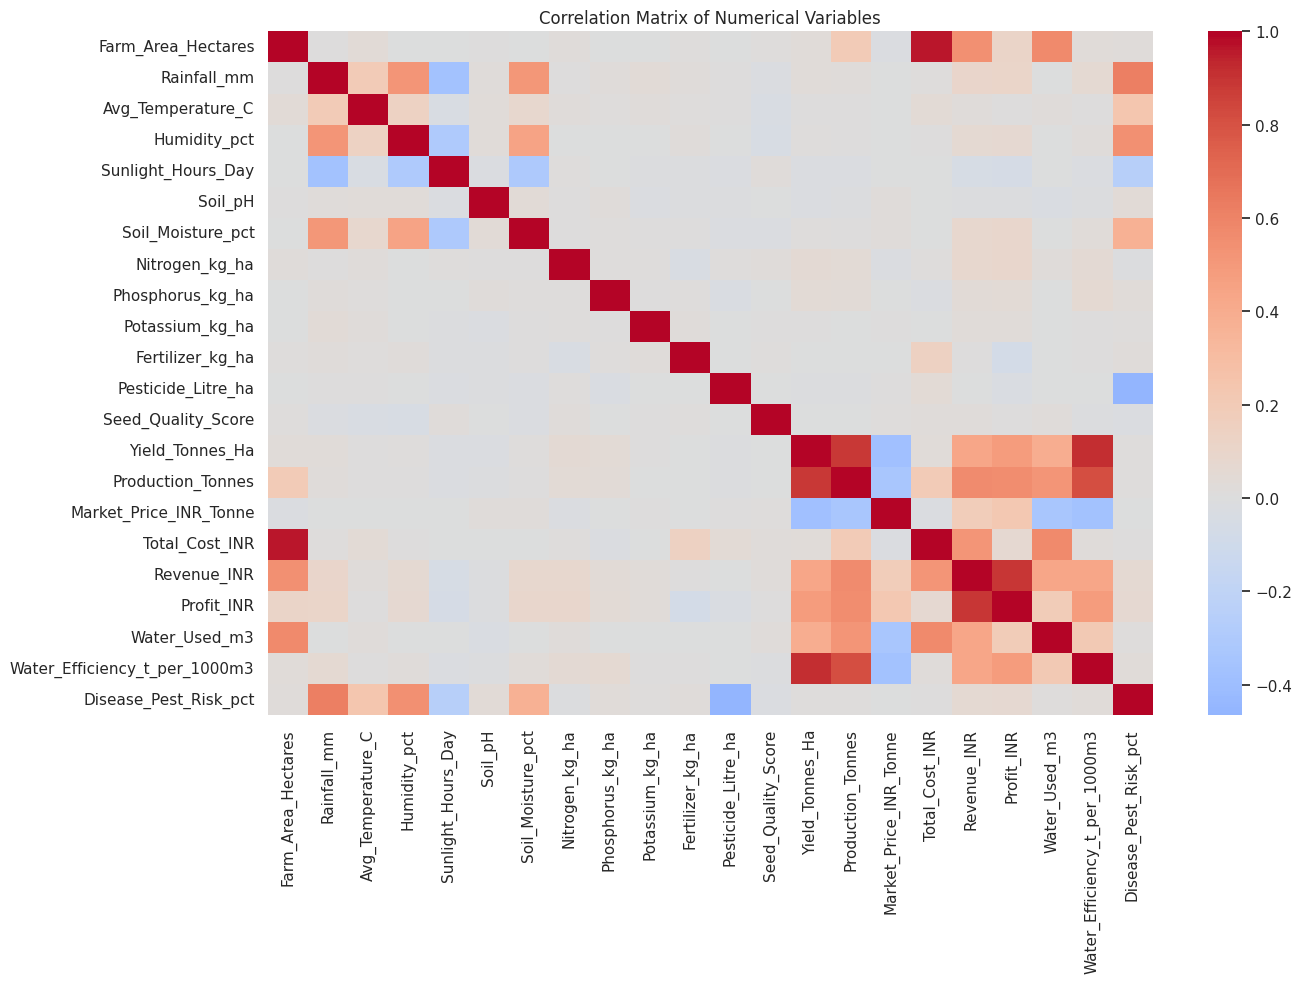

In [55]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

# 24. Multivariate Analysis
### Examines several numerical variables together using a pairplot.

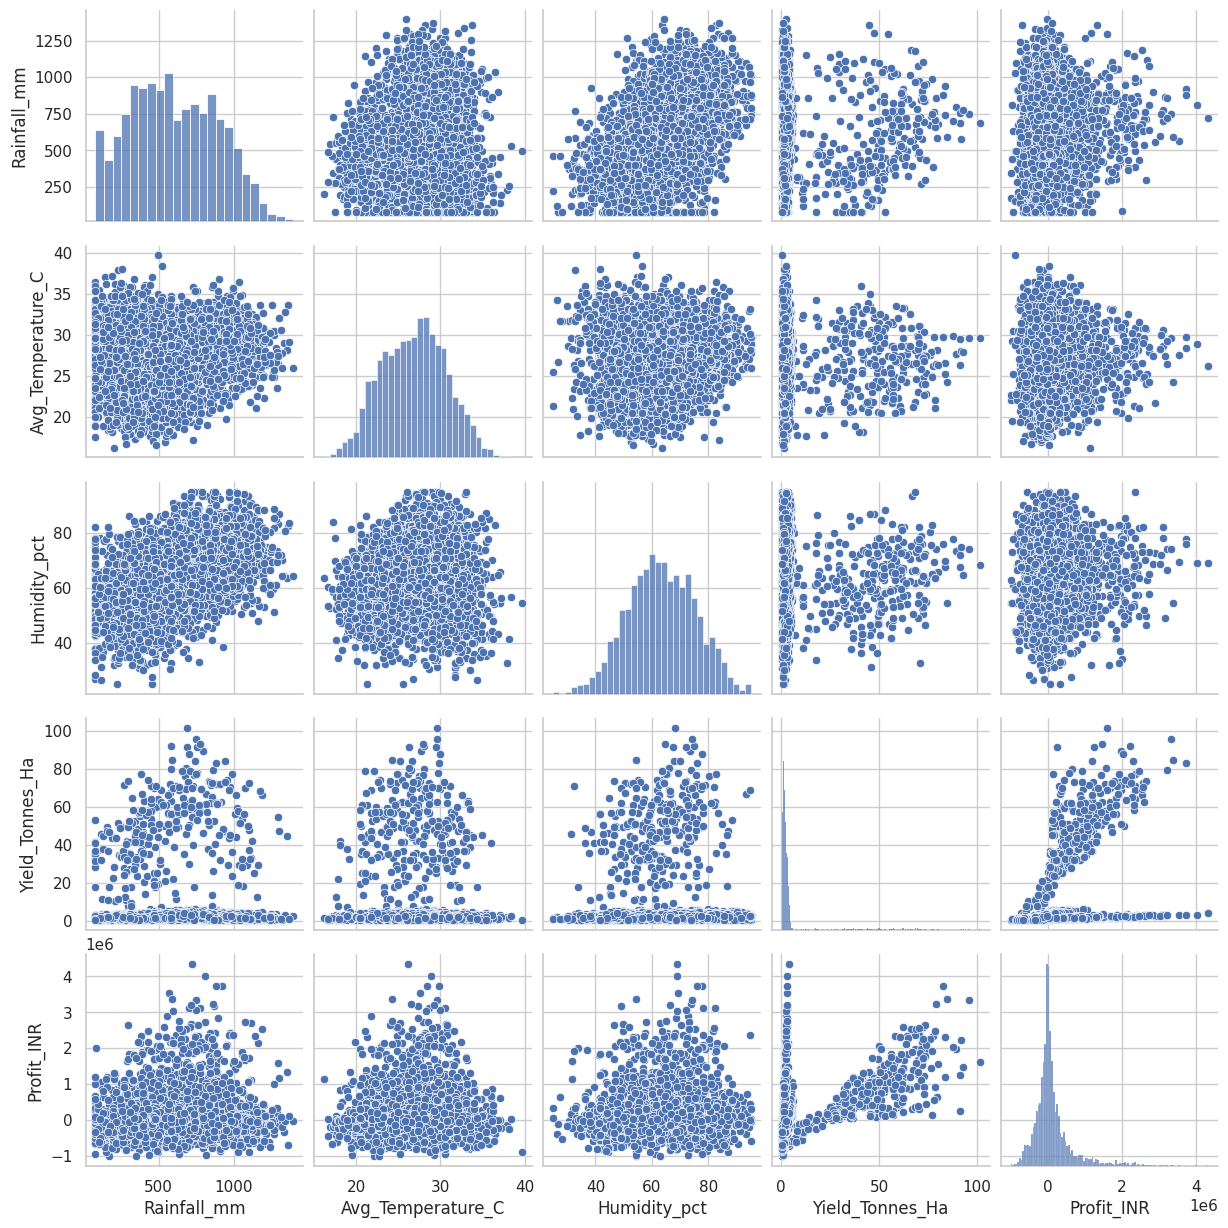

In [56]:
# Multivariate analysis

selected_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

sns.pairplot(
    df[selected_columns].dropna()
)

plt.show()

# 25. Statistical Test
### Uses ANOVA to test whether agricultural yield differs significantly between seasons.

In [57]:
# ANOVA test for yield across seasons

from scipy.stats import f_oneway

kharif_yield = df[
    df["Season"] == "Kharif"
]["Yield_Tonnes_Ha"].dropna()

rabi_yield = df[
    df["Season"] == "Rabi"
]["Yield_Tonnes_Ha"].dropna()

zaid_yield = df[
    df["Season"] == "Zaid"
]["Yield_Tonnes_Ha"].dropna()

anova_result = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA Statistic:", anova_result.statistic)
print("P-value:", anova_result.pvalue)

ANOVA Statistic: 1.4579589466621523
P-value: 0.23283549440109827


In [58]:
# Interpret the ANOVA result

if anova_result.pvalue < 0.05:
    print("There is a statistically significant difference in average yield between seasons.")
else:
    print("There is no statistically significant difference in average yield between seasons.")

There is no statistically significant difference in average yield between seasons.


# 26. Final Seasonal Summary and Key Findings

In [59]:
# Final seasonal summary

final_season_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Rainfall_mm": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Total_Cost_INR": "mean",
    "Market_Price_INR_Tonne": "mean",
    "Profit_INR": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

final_season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Rainfall_mm,Water_Used_m3,Water_Efficiency_t_per_1000m3,Total_Cost_INR,Market_Price_INR_Tonne,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,5.64,46.44,848.69,"6,094.05",5.91,"532,074.15","44,846.63","179,367.12",54.47
Rabi,5.08,41.34,437.93,"5,837.24",5.18,"513,628.29","44,770.59","88,197.25",40.52
Zaid,4.67,39.15,304.25,"6,423.08",4.44,"543,254.52","43,957.76","-26,592.40",38.22


### Best Season for Different Measures

In [60]:
# Identify best season

best_yield_season = final_season_summary["Yield_Tonnes_Ha"].idxmax()
best_profit_season = final_season_summary["Profit_INR"].idxmax()
best_water_efficiency_season = final_season_summary[
    "Water_Efficiency_t_per_1000m3"
].idxmax()
lowest_risk_season = final_season_summary[
    "Disease_Pest_Risk_pct"
].idxmin()

print("Best season for average yield:", best_yield_season)
print("Best season for average profit:", best_profit_season)
print("Best season for water efficiency:", best_water_efficiency_season)
print("Season with lowest disease/pest risk:", lowest_risk_season)

Best season for average yield: Kharif
Best season for average profit: Kharif
Best season for water efficiency: Kharif
Season with lowest disease/pest risk: Zaid


### Meaningful Insights

In [61]:
# Meaningful insights from the analysis

highest_yield = final_season_summary["Yield_Tonnes_Ha"].idxmax()
lowest_yield = final_season_summary["Yield_Tonnes_Ha"].idxmin()

highest_profit = final_season_summary["Profit_INR"].idxmax()
lowest_profit = final_season_summary["Profit_INR"].idxmin()

highest_rainfall = final_season_summary["Rainfall_mm"].idxmax()
highest_water_use = final_season_summary["Water_Used_m3"].idxmax()

highest_efficiency = final_season_summary[
    "Water_Efficiency_t_per_1000m3"
].idxmax()

lowest_risk = final_season_summary[
    "Disease_Pest_Risk_pct"
].idxmin()

best_crop = df.groupby("Crop")[
    "Yield_Tonnes_Ha"
].mean().idxmax()

best_irrigation = df.groupby("Irrigation_Method")[
    "Yield_Tonnes_Ha"
].mean().idxmax()

# Correlation of independent variables with yield

independent_variables = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score"
]

yield_correlations = df[independent_variables].corrwith(
    df["Yield_Tonnes_Ha"]
).sort_values(key=abs, ascending=False)

correlation_with_yield = yield_correlations.index[0]

print("KEY INSIGHTS")
print("--------------------------------")

print(
    "1. The season with the highest average yield is:",
    highest_yield
)

print(
    "2. The season with the lowest average yield is:",
    lowest_yield
)

print(
    "3. The season with the highest average profit is:",
    highest_profit
)

print(
    "4. The season with the lowest average profit is:",
    lowest_profit
)

print(
    "5. The season with the highest average rainfall is:",
    highest_rainfall
)

print(
    "6. The season with the highest average water usage is:",
    highest_water_use
)

print(
    "7. The season with the highest water efficiency is:",
    highest_efficiency
)

print(
    "8. The season with the lowest average disease and pest risk is:",
    lowest_risk
)

print(
    "9. The crop with the highest average yield is:",
    best_crop
)

print(
    "10. The irrigation method with the highest average yield is:",
    best_irrigation
)

print(
    "11. The independent variable with the strongest correlation with yield is:",
    correlation_with_yield
)

KEY INSIGHTS
--------------------------------
1. The season with the highest average yield is: Kharif
2. The season with the lowest average yield is: Zaid
3. The season with the highest average profit is: Kharif
4. The season with the lowest average profit is: Zaid
5. The season with the highest average rainfall is: Kharif
6. The season with the highest average water usage is: Zaid
7. The season with the highest water efficiency is: Kharif
8. The season with the lowest average disease and pest risk is: Zaid
9. The crop with the highest average yield is: Sugarcane
10. The irrigation method with the highest average yield is: Drip
11. The independent variable with the strongest correlation with yield is: Nitrogen_kg_ha


# 27. Conclusion, Recommendations and Limitations

### Evidence-Based Recommendations

In [62]:
# Evidence-based recommendations

print("RECOMMENDATIONS")
print("--------------------------------")

print(
    "1. Consider", best_yield_season,
    "when planning for higher average agricultural yield."
)

print(
    "2. Consider", best_profit_season,
    "when the main objective is higher average farm profit."
)

print(
    "3. The", best_water_efficiency_season,
    "season shows the highest average water efficiency, "
    "so water-efficient practices should be considered during seasonal planning."
)

print(
    "4. The crop with the highest average yield is",
    best_crop,
    "and its performance can be studied further for suitable seasonal conditions."
)

print(
    "5. The irrigation method with the highest average yield is",
    best_irrigation,
    "which may be considered where local conditions are suitable."
)

print(
    "6. Seasonal rainfall, water usage and environmental conditions "
    "should be considered together rather than using yield alone for planning."
)

print(
    "7. Unusual observations identified during outlier analysis "
    "should be investigated before making decisions or removing records."
)

print(
    "8. Economic indicators such as cost, market price and profit "
    "should be considered along with agricultural yield when comparing seasons."
)

RECOMMENDATIONS
--------------------------------
1. Consider Kharif when planning for higher average agricultural yield.
2. Consider Kharif when the main objective is higher average farm profit.
3. The Kharif season shows the highest average water efficiency, so water-efficient practices should be considered during seasonal planning.
4. The crop with the highest average yield is Sugarcane and its performance can be studied further for suitable seasonal conditions.
5. The irrigation method with the highest average yield is Drip which may be considered where local conditions are suitable.
6. Seasonal rainfall, water usage and environmental conditions should be considered together rather than using yield alone for planning.
7. Unusual observations identified during outlier analysis should be investigated before making decisions or removing records.
8. Economic indicators such as cost, market price and profit should be considered along with agricultural yield when comparing seasons.


### Limitations :
* The variables and observations in the dataset form the basis of the analysis.
* Although the findings might not accurately represent all possible agricultural situations, they do reveal patterns in the data that is available.
* Just because there is a correlation between two variables does not mean that one of them causes the other.
* Even though outliers were identified by means of both statistical and visual methods, they were not automatically removed since extreme results may be a sign of typical farming conditions.
* Other factors which are not contained in the dataset could also affect seasonal performance.
* Consequently, the recommendations should be seen not as definite agricultural regulations but as advice based on data.

### Conclusions :
* The analysis looked at agricultural performance over many seasons by looking at environmental factors, crop productivity, resource consumption, economic performance, and agricultural risk.

* The analysis used descriptive statistics, univariate analysis, bivariate analysis, outlier analysis, correlation analysis, and multivariate analysis in order to identify trends and connections in the data; it also carried out seasonal comparisons in order to understand the variations in yield, productivity, water use, profitability and other important factors.

* The findings indicate that agricultural performance varies from season to season and that, in evaluating the performance of agriculture on a seasonal basis, environmental, resource and economic factors all need to be considered. Therefore, the study can help to identify those areas which require further research and allow for better seasonal planning.